## Imports & Constants

In [2]:
#imports
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image, ImageOps
from dataclasses import dataclass, field
from typing import Optional, List
import io
import tempfile

from paddleocr import PaddleOCR, PPStructureV3
from pdf2image import convert_from_path
import pymupdf4llm
import pytesseract

%matplotlib inline

In [3]:
# Constants
MAX_LONG_SIDE: int = 800    # Resize longest dimension to this (px). Reduces RAM ~2-4x.
                             # Safe floor for PaddleOCR legibility: 640. Max recommended: 1280.
MIN_LONG_SIDE: int = 640    # Never downsample below this (avoids blurring small text).
CONF_THRESHOLD: float = 0.5 # Discard detections below this confidence score.

_ocr_instance = None

IMG1 = "./s1.jpeg"
IMG2 = "./s2.jpeg"
IMG3 = "./page_0.jpg"

In [3]:
ocr = PaddleOCR(
    use_doc_orientation_classify=True,
    use_doc_unwarping=True,
    use_textline_orientation=True,
    enable_mkldnn=False
)

/home/rishicarter/git/AIAgents/.venv/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/rishicarter/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/rishicarter/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/rishicarter/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creatin

## Explore

In [ ]:
dir(PaddleOCR)

In [ ]:
dir(ocr.predict)

In [ ]:
PaddleOCR??

In [31]:
import fitz

IMG_PATH = "images/invoice1.pdf"
IMG_PATH2 = "images/invoice2.pdf"

docs = fitz.open(IMG_PATH2)
len(docs), type(docs)

(4, pymupdf.Document)

In [38]:
docs[0].get_text()

''

## Preprocessing Code

In [ ]:
import cv2
import numpy as np
import pytesseract
import pymupdf4llm
import tempfile
from PIL import Image, ImageFilter, ImageEnhance

# ─────────────────────────────────────────────
# 1. TESSERACT CONFIG — tuned for invoices
# ─────────────────────────────────────────────

INVOICE_CONFIG = (
    "--oem 3 "
    "--psm 6 "
    "-l eng+hin+osd "
    "-c preserve_interword_spaces=1 "
    "-c textord_heavy_nr=1 "
    "-c edges_max_children_per_outline=40 "
)

# PSM reference for invoices:
# psm 4  — single column (good for single-column invoices)
# psm 6  — uniform block (default sweet spot for mixed invoices)
# psm 11 — sparse text, no OSD (useful for fragmented/rotated layouts)
# psm 12 — sparse text with OSD


# ─────────────────────────────────────────────
# 2. IMAGE PREPROCESSING
# ─────────────────────────────────────────────

def preprocess_invoice_image(pil_image: Image.Image) -> Image.Image:
    """
    Full preprocessing pipeline for invoice images before OCR.
    """
    img = np.array(pil_image.convert("RGB"))

    # Step 1: Upscale if resolution is too low (Tesseract prefers 300 DPI)
    h, w = img.shape[:2]
    if max(h, w) < 2000:
        scale = 2000 / max(h, w)
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # Step 2: Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Step 3: Deskew — invoices often come in slightly rotated scans
    gray = deskew(gray)

    # Step 4: Denoise
    gray = cv2.fastNlMeansDenoising(gray, h=10, templateWindowSize=7, searchWindowSize=21)

    # Step 5: Adaptive thresholding — handles uneven lighting / shadows on scanned invoices
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31,   # larger block handles broader shadows
        C=15
    )

    # Step 6: Morphological cleanup — removes small speckles without touching text
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 1))
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    return Image.fromarray(binary)


def deskew(gray: np.ndarray) -> np.ndarray:
    """Correct rotation using Hough line detection."""
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=200)

    if lines is not None:
        angles = [line[0][1] for line in lines]
        median_angle = np.median(angles)
        skew_deg = (median_angle - np.pi / 2) * (180 / np.pi)

        if abs(skew_deg) < 10:  # Only correct minor skews; avoid flipping
            (h, w) = gray.shape
            center = (w // 2, h // 2)
            M = cv2.getRotationMatrix2D(center, skew_deg, 1.0)
            gray = cv2.warpAffine(
                gray, M, (w, h),
                flags=cv2.INTER_CUBIC,
                borderMode=cv2.BORDER_REPLICATE
            )
    return gray


# ─────────────────────────────────────────────
# 3. FULL OCR → MARKDOWN PIPELINE
# ─────────────────────────────────────────────

def invoice_ocr_pipeline(pil_image: Image.Image) -> str:
    """
    End-to-end: PIL image → preprocessed → Tesseract hOCR → PDF → Markdown.
    """
    # Preprocess
    clean_img = preprocess_invoice_image(pil_image)

    # Generate searchable PDF with hOCR (preserves layout + bounding boxes)
    img_pdf = pytesseract.image_to_pdf_or_hocr(
        clean_img,
        extension="pdf",
        config=INVOICE_CONFIG
    )

    with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as tmp:
        tmp.write(img_pdf)
        tmp_path = tmp.name

    # Convert to Markdown — pymupdf4llm preserves table structure well
    md_text = pymupdf4llm.to_markdown(
        tmp_path,
        # Optional: extract tables as markdown tables
        # table_strategy="lines_strict"  # if pymupdf4llm version supports it
    )

    return md_text


# ─────────────────────────────────────────────
# 4. STRUCTURED DATA EXTRACTION (post-OCR)
# ─────────────────────────────────────────────

import re

def extract_invoice_fields(md_text: str) -> dict:
    """
    Regex-based extraction of common invoice fields from markdown output.
    Extend patterns as needed for your invoice format.
    """
    patterns = {
        "invoice_number": r"(?:Invoice\s*(?:No|Number|#)[:\s#]*)([\w\-/]+)",
        "invoice_date":   r"(?:Date|Invoice\s*Date)[:\s]*([\d]{1,2}[\s/\-.][\d]{1,2}[\s/\-.][\d]{2,4})",
        "due_date":       r"(?:Due\s*Date|Payment\s*Due)[:\s]*([\d]{1,2}[\s/\-.][\d]{1,2}[\s/\-.][\d]{2,4})",
        "total_amount":   r"(?:Total|Grand\s*Total|Amount\s*Due)[:\s₹$€£]*([\d,]+\.?\d*)",
        "tax_amount":     r"(?:Tax|GST|VAT|IGST|CGST|SGST)[:\s₹$€£%]*([\d,]+\.?\d*)",
        "vendor_gstin":   r"GSTIN[:\s]*([0-9]{2}[A-Z]{5}[0-9]{4}[A-Z]{1}[1-9A-Z]{1}Z[0-9A-Z]{1})",
    }

    extracted = {}
    for field, pattern in patterns.items():
        match = re.search(pattern, md_text, re.IGNORECASE)
        extracted[field] = match.group(1).strip() if match else None

    return extracted


# ─────────────────────────────────────────────
# 5. USAGE
# ─────────────────────────────────────────────

md_text = invoice_ocr_pipeline(IMG3)
fields  = extract_invoice_fields(md_text)

print(md_text)
print(fields)

In [58]:
def _preprocess(image_path: Optional[str | Path | Image.Image]) -> tuple[np.ndarray, tuple[int, int]]:
    """
    Load and preprocess an image for PaddleOCR:
      1. EXIF-aware load  → corrects phone/camera auto-rotation (portrait vs landscape).
      2. RGB conversion   → strips alpha channel, normalises colour space.
      3. Smart resize     → shrinks high-res inputs to MAX_LONG_SIDE on the longest axis,
                            keeping aspect ratio. Never upscales small images.
                            Uses INTER_AREA (best quality for downsampling).

    Returns:
        img_rgb  : preprocessed uint8 NumPy array (H, W, 3) ready for PaddleOCR.
        orig_hw  : (H, W) of the original image before resizing.
    """
    # --- 1. Load & honour EXIF rotation ---
    if not isinstance(image_path, Image.Image):
        pil_img = Image.open(image_path)
    else:
        pil_img = image_path.copy()
    pil_img = ImageOps.exif_transpose(pil_img)  # Rotates in-memory; no quality loss

    # --- 2. Ensure RGB (drop alpha, handle palette/grayscale) ---
    img_rgb = np.array(pil_img.convert("RGB"), dtype=np.uint8)
    orig_hw = img_rgb.shape[:2]   # (H, W)
    h, w = orig_hw

    # --- 3. Resize: longest side → MAX_LONG_SIDE (only downscale) ---
    long_side = max(h, w)
    if long_side > MAX_LONG_SIDE:
        scale = MAX_LONG_SIDE / long_side
        new_h = max(int(h * scale), MIN_LONG_SIDE if h >= w else 1)
        new_w = max(int(w * scale), MIN_LONG_SIDE if w > h else 1)
        img_rgb = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)
        print(
            f"Resized {w}x{h} → {new_w}x{new_h}",
        )
    else:
        print(f"Image {w}x{h} is within limits — no resize needed.")

    return img_rgb, orig_hw

In [56]:
def pdf_processed_images(file_path: str) -> List[tuple[Image.Image, Image.Image]]:
    pages = convert_from_path(file_path)

    processed_images = []

    for _, page in enumerate(pages):
        processed_page_img, _ = _preprocess(page)
        processed_images.append((page, processed_page_img))
    
    return processed_images


In [15]:
def _get_ocr():
    """
    Initialise PaddleOCR once and reuse across calls.
    CPU-only: use_gpu=False, use_angle_cls=True (handles rotated text).
    """
    global _ocr_instance
    if _ocr_instance is None:
        try:
            from paddleocr import PaddleOCR
        except ImportError as e:
            raise ImportError(
                "PaddleOCR is not installed. Run:\n"
                "  pip install paddlepaddle paddleocr"
            ) from e

        print("Initialising PaddleOCR (CPU) — first call downloads model weights (~30 MB).")
        _ocr_instance = PaddleOCR(
            use_textline_orientation=True,   # Correct 90°/180°/270° text rotation
            lang="en",            # Change to "ch", "hi", etc. for other languages
            # use_gpu=False,        # CPU inference
            # show_log=False,       # Suppress PaddlePaddle verbose output
            enable_mkldnn=False,   # Intel MKL-DNN acceleration on x86 CPUs (free perf boost)
        )
        print("PaddleOCR ready.")
    return _ocr_instance

## Code & Visualise

In [ ]:
openrouter_provider_dict = {
    "google/gemma-4-31b-it:free": ["open-inference/bf16", "google-ai-studio"]
}

Resized 1700x2200 → 618x800


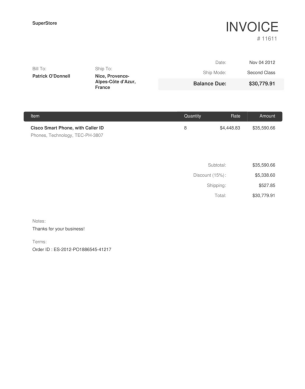

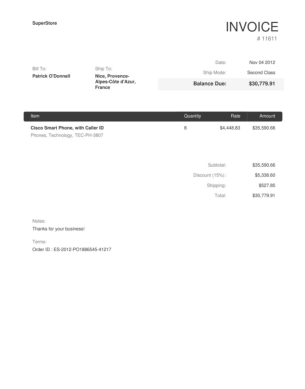

In [25]:
i1 = cv2.imread(IMG3)
img_rgb = cv2.cvtColor(i1, cv2.COLOR_BGR2RGB)

processed_rgb, _ = _preprocess(IMG3)

plt.imshow(img_rgb)
plt.axis('off')
plt.show()
plt.imshow(processed_rgb)
plt.axis('off')
plt.show();

In [39]:
results = ocr.predict(processed_rgb)

full_text = ""

for page in results:
    full_text += "\n".join(page["rec_texts"])

print(full_text)

SuperStore
INVOICE
#11611
Date:
Nov 04 2012
Bill To:
Ship To:
Patrick O'Donnell
Ship Mode:
Second Class
Nice,Provence-
Alpes-Cote d'Azur,
Balance Due:
$30,779.91
France
Item
Quantity
Rate
Amount
Cisco Smart Phone, with Caller ID
8
$4,448.83
$35,590.66
Phones, Technology, TEC-PH-3807
Subtotal:
$35,590.66
Discount (15%):
$5,338.60
Shipping:
$527.85
Total:
$30,779.91
Notes:
Thanks for your business!
Terms:
Order ID :ES-2012-PO1886545-41217


In [40]:
for res in results:
    # Save visualized image directly
    res.save_to_img("output")

Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/PaddleX3.0/fonts/simfang.ttf ...
[==================================================] 100.00%
Connecting to https://paddle-model-ecology.bj.bcebos.com/paddlex/PaddleX3.0/fonts/PingFang-SC-Regular.ttf ...
[==================================================] 100.00%


In [41]:
results_pdf = ocr.predict("./images/invoice1.pdf")

full_text = ""

for page in results_pdf:
    full_text += "\n".join(page["rec_texts"])

print(full_text)

INVOICE
#11611
Date:
Nov 04 2012
Bill To:
Ship To:
Ship Mode:
Second Class
Patrick O'Donnell
Nice, Provence-
Alpes-Cote d'Azur,
Balance Due:
$30,779.91
France
ltem
Quantity
Rate
Amount
Cisco Smart Phone, with Caller ID
8
$4,448.83
$35,590.66
Phones, Technology, TEC-PH-3807
Subtotal:
$35,590.66
$5,338.60
Discount (15%):
Shipping:
$527.85
Total:
$30,779.91
Notes:
Thanks for your business!
Terms:
Order ID : ES-2012-PO1886545-41217


In [50]:
for res in results_pdf:
    # Save visualized image directly
    res.save_to_img("output")

In [49]:
type(results_pdf[0])

paddlex.inference.pipelines.ocr.result.OCRResult

Resized 1700x2200 → 618x800


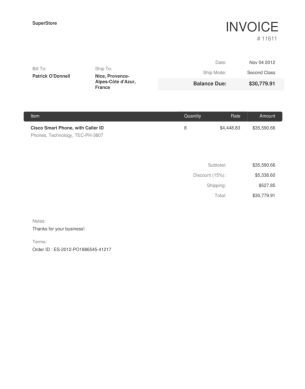

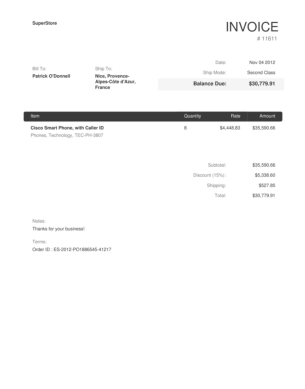

In [73]:
pdf_pages = pdf_processed_images("./images/invoice1.pdf")
for pdf_page in pdf_pages:
    if not pdf_page:
        continue
    (raw_img, process_img) = pdf_page
    # i1 = cv2.imread(raw_img)
    # img_rgb = cv2.cvtColor(i1, cv2.COLOR_BGR2RGB)

    # processed_rgb, _ = _preprocess(IMG3)

    plt.imshow(raw_img)
    plt.axis('off')
    plt.show()
    plt.imshow(process_img)
    plt.axis('off')
    plt.show();

In [74]:
# 4 mins for 4 pages on CPU with 2.5 GB RAM

processed_images = [i[1] for i in pdf_pages]
results = ocr.predict(processed_images)

full_text = ""

for page in results:
    full_text += "\n".join(page["rec_texts"])

print(full_text)

SuperStore
INVOICE
#11611
Date:
Nov 04 2012
Bill To:
Ship To:
Patrick O'Donnell
Ship Mode:
Second Class
Nice, Provence-
Alpes-Cote d'Azur,
Balance Due:
$30,779.91
France
Item
Quantity
Rate
Amount
Cisco Smart Phone, with Caller ID
8
$4,448.83
$35,590.66
Phones, Technology, TEC-PH-3807
Subtotal:
$35,590.66
Discount (15%):
$5,338.60
Shipping:
$527.85
Total:
$30,779.91
Notes:
Thanks for your business!
Terms:
Order ID : ES-2012-PO1886545-41217


In [72]:
for res in results:
    # Save visualized image directly
    res.save_to_img("output")

In [6]:
res: str = pymupdf4llm.to_markdown("./images/invoice2.pdf")
res

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=2/3.
OCR on page.number=3/4.



Image too small to scale!! (2x36 vs min width of 3)
Line cannot be recognized!!


'“J \n\n| | \n\n| \n\n**==> picture [178 x 44] intentionally omitted <==**\n\n**----- Start of picture text -----**<br>\n7 :<br>— =.oe)oe) cioudExtel<br>: =<br>}<br>**----- End of picture text -----**<br>\n\n\n**==> picture [509 x 740] intentionally omitted <==**\n\n**----- Start of picture text -----**<br>\n: Excel Telesonic India Pvt Lid<br>— =.oe)oe) cioudExtel M.No 9/28, M.1.G, Rampuram Daheii.Gi, Sulanpur,suis<br>= Kanpur Nagar, Uttar Pradesh - 208014<br>GST No: 09AACCE9168)124<br>CIN No: U74999MH2010PTO2072293<br>TAX INVOICE<br>ETS0926050033<br>Original for Recipient<br>Date: Company GSTIN:<br>29-05-2026 OSAACCES168J1Z4<br>Payment Due Date: Company PAN No:<br>28-06-2026 ; AAGGES168J<br>Bill to Section Ship to Section<br>Customer Name: Excel Telesonic India Customer Name: Excel Telesonic India<br>. Private Limited - Private Limited-<br>Customer is ‘Customer<br>Customer PAN no: AACCES168) Shipping Address: Khata Number 545/628,<br>645/755, Khasra Number<br>Address: industrialD-152,

In [19]:

img = Image.open("./page_0.jpg").convert("RGB")

temp_pdf = io.BytesIO()
img.save(temp_pdf, format="PDF")

with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as tmp:
    tmp.write(temp_pdf.getvalue())
    tmp_path = tmp.name

res: str = pymupdf4llm.to_markdown(tmp_path)

=== Document parser messages ===
                                                                                                                                                                                                                                    Using Tesseract for OCR processing.
OCR on page.number=0/1.



In [17]:
type(temp_pdf.getvalue())

bytes

In [4]:
pytesseract.image_to_string(IMG3)

"Superstore INVOICE\n\n#11611\nDate: Nov 04 2012\nBill To: Ship To: .\n. . Ship Mode: Second Class\nPatrick O'Donnell Nice, Provence-\nAlpes-Cote d'Azur, Balance Due: $30,779.91\nFrance\nheya (eETa tiny Rate Amount\nCisco Smart Phone, with Caller ID 8 $4,448.83 $35,590.66\nPhones, Technology, TEC-PH-3807\nSubtotal: $35,590.66\nDiscount (15%): $5,338.60\nShipping: $527.85\nTotal: $30,779.91\n\nNotes:\n\nThanks for your business!\n\nTerms:\nOrder ID : ES-2012-PO01886545-41217\n\x0c"

In [5]:
img_pdf = pytesseract.image_to_pdf_or_hocr(IMG3)

In [9]:
type(img_pdf)

bytes

In [10]:
with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as tmp:
    tmp.write(img_pdf)
    tmp_path = tmp.name

md_text: str = pymupdf4llm.to_markdown(tmp_path)
    # if not md_text.strip():
    #     pass
md_text
# md_text: str = pymupdf4llm.to_markdown(img_pdf)

=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.



"“ewes \n\n# 11611 \n\n## INVOICE \n\n|Date:|Nov 04 2012|\n|---|---|\n|Si ine<br>oo|ici<br>econ<br>ass|\n|BalanceDue:|$30,779.91|\n\n\n\n||||Date:|Nov 04 2012|\n|---|---|---|---|---|\n|Bill To:<br>PatrickO'Donnell|Ship To:<br>Nice, Provence-||Si ine<br>oo|ici<br>econ<br>ass|\n||Alpes-Cote d'Azur,<br>France|Balance Due:||$30,779.91|\n|ltem||Quantity|tclic|Amount|\n|Cisco Smart Phone, with Caller ID||8|$4,448.83|$35,590.66|\n|Phones, Technology, TEC-PH-3807|||||\n||||Subtotal:|$35,590.66|\n|||Discount (15%):||$5,338.60|\n||||Shipping:|$527.85|\n||||Total:|$30,779.91|\n\n\n\n## Notes: \n\nThanks for your business! \n\nTerms: Order ID : ES-2012-P0O1886545-41217 \n\n"